# Verify OCT Rotation

Verify the rotation of OCT frames by interpolated angles using rotate_oct.py

In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
from pydicom import dcmread
from pathlib import Path
import re
import json

# Read in data
oct_sb_labels = pd.read_csv('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/OCT_SB_labels.csv')

# Function to search for file path in subdirectories
def file_search(search_dir, filename):

    file_path = next(
        (f for f in search_dir.rglob(filename) if f.is_file()),
        None
    )

    if file_path:
        print(f"Found: {file_path}")
    else:
        print(f"No file found for {filename}")

    return file_path

In [ ]:
# Search for filename in rotated folder

# Find it in oct_sb_labels dataset 
# Extract the frame id 

# plot and visualise

In [93]:
# Choose vessel to compare and analyse 
# Select only vessels with bounding boxes to check
full_filename = oct_sb_labels[oct_sb_labels['region_count']>0]['filename'].sample(n=1).iloc[0]
filename = full_filename.removesuffix(".jpg")
filename = filename[5:]
filename, frame_id = re.match(r"^(.*)_(\d{4})$", filename).groups()
frame_id = int(frame_id)
print(f'Vessel:{filename} frame:{frame_id}')

# Check the data
oct_sb_labels[oct_sb_labels['filename']==full_filename]

Vessel:BERN-039-RCA_FU frame:140


,Unnamed: 0,filename,region_count,region_shape_attributes,class,set
2220,2557,0143_BERN-039-RCA_FU_0140.jpg,1,"{""name"":""rect"",""x"":123,""y"":523,""width"":304,""he...",sb,train


## Check original DICOMS

Found: /home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS/BERN-039-RCA_FU/BERN-039-RCA_FU.dcm
(375, 1024, 1024)


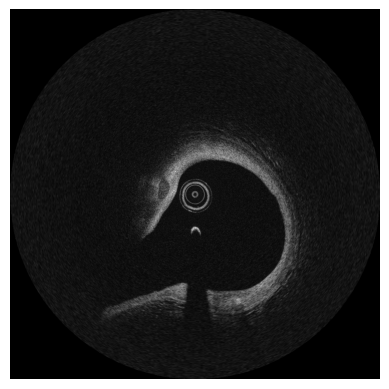

In [94]:
dicom_dir = Path('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/external/DICOMS')
dicom_file = filename + '.dcm'

dicom_path = file_search(dicom_dir, dicom_file)

# Check shape of DICOMs
ds = dcmread(dicom_path)
arr = ds.pixel_array
print(arr.shape)

# Visualise
plt.imshow(ds.pixel_array[frame_id], cmap="gray")
plt.axis("off")
plt.show()

## Check rotated OCT

Found: /home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/raw/rotated_octs/BERN-041-RCA_FU_rotated.npy
(375, 1024, 1024)


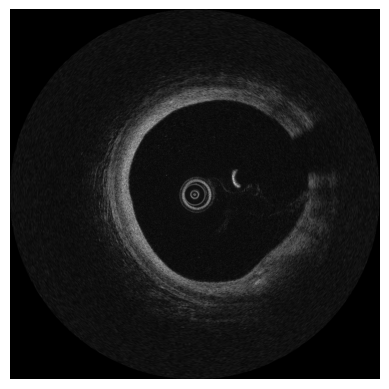

In [132]:
# For the purpose of testing, pick a name 
test_file = 'BERN-041-RCA_FU'

# Add the suffix
rotated_file = test_file + "_rotated.npy"

# Search in folder
dir = Path('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/data/raw/rotated_octs')
rotated_path = file_search(dir, rotated_file)

image_arr = np.load(rotated_path)
print(image_arr.shape)

# Visualise
plt.imshow(image_arr[1], cmap="gray")
plt.axis("off")
plt.show()


## Visualise bounding boxes

(1024, 1024)
352 124 214 276


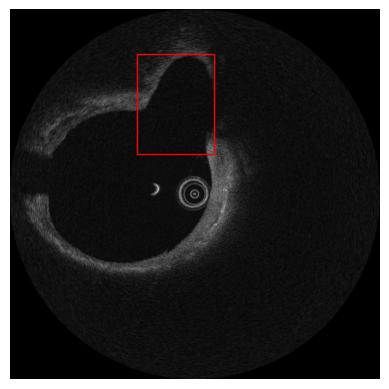

In [134]:
# Use original filename
test_data = oct_sb_labels[(oct_sb_labels['filename'].str.contains(test_file, na=False)) & (oct_sb_labels['region_count']>0)].iloc[0]
test_frame_id = int(re.search(r'(\d{4})\.jpg$', test_data['filename']).group(1))

# get bounding box coordinates
bbox = json.loads(test_data['region_shape_attributes'])

x = bbox['x']
y = bbox['y']
w = bbox['width']
h = bbox['height']

# Check dimensions
print(image_arr[test_frame_id].shape)
print(x, y, w, h)

# Plot with bounding box
fig, ax = plt.subplots()

ax.imshow(image_arr[test_frame_id], cmap="gray")

rect = patches.Rectangle((x, y),w,h,linewidth=1,edgecolor='r',facecolor='none')
ax.add_patch(rect)
ax.axis("off")
plt.show()